# Setup e imports

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

GRAPH_PATH = "../outputs/graphs/association_graph.graphml"
PLOTS_DIR = "../outputs/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# 1. Carregamento do grafo

In [2]:
# Fonte: outputs/graphs/association_graph.graphml
G = nx.read_graphml(GRAPH_PATH)

print(f"Arquivo: {GRAPH_PATH}")

Arquivo: ../outputs/graphs/association_graph.graphml


# 2. Tamanho do grafo

In [3]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

if G.is_directed():
    # Para grafos dirigidos, grau = in_degree + out_degree
    degrees = [d for _, d in G.degree()]
else:
    degrees = [d for _, d in G.degree()]

avg_degree = np.mean(degrees)

print(f"Vértices:    {n_nodes:,}")
print(f"Arestas:     {n_edges:,}")
print(f"Grau médio:  {avg_degree:.4f}")

Vértices:    39,180
Arestas:     6,205,788
Grau médio:  316.7835


# 3. Distribuição dos graus

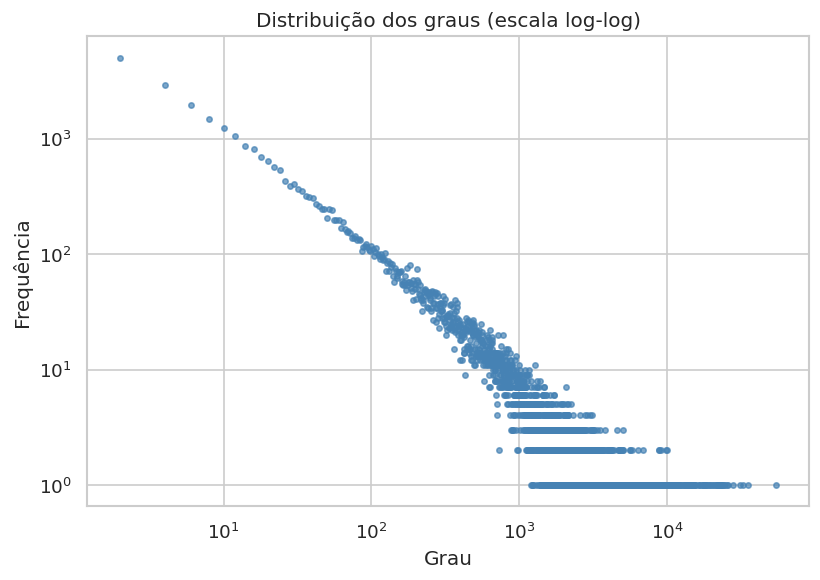

Grau mínimo:  2
Grau máximo:  54500
Grau mediano: 34.0


In [4]:
degree_counts = Counter(degrees)
degree_values = sorted(degree_counts.keys())
degree_freqs  = [degree_counts[d] for d in degree_values]

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(degree_values, degree_freqs, s=10, color="steelblue", alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Distribuição dos graus (escala log-log)")
ax.set_xlabel("Grau")
ax.set_ylabel("Frequência")

plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "distribuicao_graus_loglog.png"), bbox_inches="tight")
plt.show()

print(f"Grau mínimo:  {min(degrees)}")
print(f"Grau máximo:  {max(degrees)}")
print(f"Grau mediano: {np.median(degrees):.1f}")

# 4. Componentes conexas

In [5]:
if G.is_directed():
    components = list(nx.strongly_connected_components(G))
    component_type = "fortemente conexas"
else:
    components = list(nx.connected_components(G))
    component_type = "conexas"

n_components = len(components)
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"Número de componentes {component_type}: {n_components:,}")
print(f"Maior componente:  {component_sizes[0]:,} vértices ({100 * component_sizes[0] / n_nodes:.1f}% do total)")
if n_components > 1:
    print(f"Menor componente:  {component_sizes[-1]:,} vértice(s)")
    print(f"Tamanho mediano:   {np.median(component_sizes):.0f} vértice(s)")

Número de componentes fortemente conexas: 272
Maior componente:  35,815 vértices (91.4% do total)
Menor componente:  2 vértice(s)
Tamanho mediano:   2 vértice(s)


# 5. Distribuição dos tamanhos das componentes

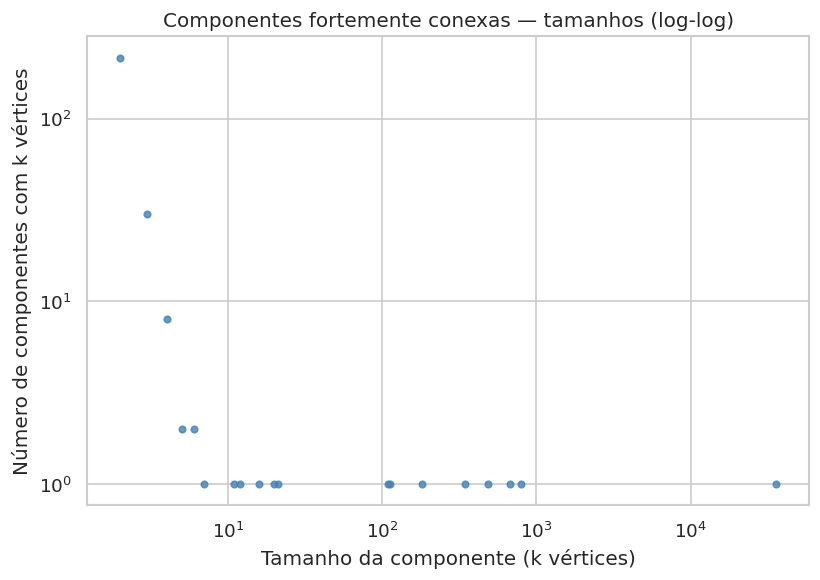

In [6]:
if n_components == 1:
    print("O grafo possui apenas uma componente — nenhuma distribuição a exibir.")
else:
    size_counts = Counter(component_sizes)
    sizes  = sorted(size_counts.keys())
    counts = [size_counts[s] for s in sizes]

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(sizes, counts, s=15, color="steelblue", alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Componentes {component_type} — tamanhos (log-log)")
    ax.set_xlabel("Tamanho da componente (k vértices)")
    ax.set_ylabel("Número de componentes com k vértices")

    plt.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, "componentes_tamanhos_loglog.png"), bbox_inches="tight")
    plt.show()